<a href="https://colab.research.google.com/github/Diegoggonfer/Modelos/blob/main/Modelo_DRP_2_Prediccion_sobre_dataset_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Carga Inicial de Datos

In [ ]:
import pandas as pd

# Cargar los datos
data = pd.read_csv('/content/drive/MyDrive/TFM/nuevo set/GDSC_DATASET.csv')

print("Nombres de las columnas:")
print(data.columns.tolist())

print("\nDimensiones del dataset:")
print(data.shape)

print("\nPrimeras 5 filas del dataset:")
display(data.head())

Nombres de las columnas:
['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']

Dimensiones del dataset:
(242035, 19)

Primeras 5 filas del dataset:


,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


### Preprocesamiento de los Datos

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar los datos
data = pd.read_csv('/content/drive/MyDrive/TFM/nuevo set/GDSC_DATASET.csv')

# Eliminar filas sin variable objetivo y separarla del resto.
# Esta debe ser la primera operación para asegurar que el target sea limpio y consistente.
original_rows_count = data.shape[0]
data.dropna(axis=0, subset=['LN_IC50'], inplace=True)
target = data['LN_IC50']
data.drop(['LN_IC50'], axis=1, inplace=True)
print(f"Filas después de eliminar NaNs en LN_IC50: {data.shape[0]} (original: {original_rows_count})")

# Columnas a eliminar según la nueva solicitud del usuario
columns_to_drop = ['COSMIC_ID', 'DRUG_ID', 'AUC', 'Z_SCORE']
data.drop(columns=columns_to_drop, errors='ignore', inplace=True)
print(f"Filas después de eliminar columnas especificadas: {data.shape[0]}")

# Identificar columnas numéricas y categóricas para un manejo diferenciado
numeric_cols = []
categorical_cols = []

for col in data.columns:
    # Intentar convertir la columna a numérica. Los errores se convierten en NaN.
    temp_series = pd.to_numeric(data[col], errors='coerce')

    # Si la serie temporal tiene un tipo numérico (float o int) Y NO está compuesta enteramente de NaNs (lo que indicaría que no se pudo convertir nada útil)
    # y la proporción de valores no NaN es alta, la consideramos numérica.
    # Usamos un umbral para considerar que una columna es principalmente numérica.
    non_nan_ratio = temp_series.count() / data[col].count()
    if pd.api.types.is_numeric_dtype(temp_series) and non_nan_ratio > 0.5: # Si más del 50% de los valores pudieron ser convertidos a numéricos
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print(f"\nColumnas Numéricas Identificadas: {numeric_cols}")
print(f"Columnas Categóricas Identificadas: {categorical_cols}")

# Manejar columnas numéricas: eliminar filas con NaNs
print(f"\nFilas antes de eliminar NaNs en columnas numéricas: {data.shape[0]}")
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce') # Asegurar que sean numéricas, convirtiendo cualquier texto no numérico a NaN
data.dropna(subset=numeric_cols, inplace=True) # Eliminar filas donde estas columnas numéricas tienen NaNs
target = target.loc[data.index] # Reajustar el target después de eliminar filas
print(f"Filas después de eliminar NaNs en columnas numéricas: {data.shape[0]}")

# Manejar columnas categóricas: reemplazar NaN y 'Unclassified' con 'Desconocido'
print(f"\nFilas antes de procesar columnas categóricas: {data.shape[0]}")
for col in categorical_cols:
    # Convertir a tipo string para asegurar que .replace() y .fillna() funcionen correctamente
    data[col] = data[col].astype(str)
    data[col] = data[col].replace('Unclassified', "Desconocido") # Reemplazar 'Unclassified'
    data[col] = data[col].replace('UNCLASSIFIED', "Desconocido") # Reemplazar 'Unclassified'
    data[col] = data[col].replace('nan', "Desconocido") # Reemplazar NaNs que se hayan convertido a string 'nan'
    data[col] = data[col].fillna("Desconocido") # Rellenar cualquier NaN remanente

print(f"Filas después de procesar columnas categóricas: {data.shape[0]}")

# Separar el set de validación del de entrenamiento
X_train, X_valid, y_train, y_valid = train_test_split(data, target, train_size=0.8, test_size=0.2, random_state=0)

print("\nDimensiones de X_train:")
print(X_train.shape)
print("Primeras 5 filas de X_train:")
display(X_train.head())

print("\nDimensiones de y_train:")
print(y_train.shape)
print("Primeras 5 filas de y_train:")
display(y_train.head())

Filas después de eliminar NaNs en LN_IC50: 242035 (original: 242035)
Filas después de eliminar columnas especificadas: 242035

Columnas Numéricas Identificadas: []
Columnas Categóricas Identificadas: ['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']

Filas antes de eliminar NaNs en columnas numéricas: 242035
Filas después de eliminar NaNs en columnas numéricas: 242035

Filas antes de procesar columnas categóricas: 242035
Filas después de procesar columnas categóricas: 242035

Dimensiones de X_train:
(193628, 14)
Primeras 5 filas de X_train:


,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
226764,LS-1034,COREAD,CT7033-2,large_intestine,large_intestine,COAD/READ,MSS/MSI-L,R,Adherent,Y,Y,Y,"KDM4A, KDM4C, KDM4E, KDM3A, KDM6B",Chromatin histone methylation
169505,NCI-H226,LUSC,BEN,lung_NSCLC,lung_NSCLC_squamous_cell_carcinoma,LUSC,MSS/MSI-L,R,Adherent,Y,Y,Y,Desconocido,Desconocido
28185,ESS-1,Desconocido,Doramapimod,urogenital_system,endometrium,Desconocido,MSS/MSI-L,R,Adherent,Y,Y,Y,"p38, JNK2",JNK and p38 signaling
150708,OE21,ESCA,Fludarabine,aero_dig_tract,oesophagus,ESCA,MSS/MSI-L,R,Adherent,Y,Y,Y,Antimetabolite,DNA replication
57432,KATOIII,STAD,GSK1904529A,digestive_system,stomach,STAD,MSS/MSI-L,D/F12,Semi-Adherent,Y,Y,Y,"IGF1R, IR",IGF1R signaling



Dimensiones de y_train:
(193628,)
Primeras 5 filas de y_train:


,LN_IC50
226764,1.270521
169505,8.767445
28185,5.028930
150708,6.488667
57432,3.705918


### Análisis de los valores desconocidos en el dataset

In [ ]:
print("\nAnálisis de valores 'Desconocidos' por columna:")
total_rows = data.shape[0]

unknown_counts = {}
unknown_percentages = {}

for col in data.columns:
    if data[col].dtype == 'object': # Solo para columnas que pueden contener strings 'Desconocido'
        count = (data[col] == 'Desconocido').sum()
        if count > 0:
            unknown_counts[col] = count
            unknown_percentages[col] = (count / total_rows) * 100

if unknown_counts:
    print("Número de valores 'Desconocidos' por columna:")
    for col, count in unknown_counts.items():
        print(f"  - {col}: {count}")

    print("\nPorcentaje de valores 'Desconocidos' por columna:")
    for col, percentage in unknown_percentages.items():
        print(f"  - {col}: {percentage:.2f}%")
else:
    print("No se encontraron valores 'Desconocidos' en las columnas categóricas.")


Análisis de valores 'Desconocidos' por columna:
Número de valores 'Desconocidos' por columna:
  - TCGA_DESC: 46757
  - GDSC Tissue descriptor 1: 9366
  - GDSC Tissue descriptor 2: 9366
  - Cancer Type (matching TCGA label): 51446
  - Microsatellite instability Status (MSI): 12353
  - Screen Medium: 9366
  - Growth Properties: 9366
  - CNA: 9366
  - Gene Expression: 9366
  - Methylation: 9366
  - TARGET: 27155
  - TARGET_PATHWAY: 24979

Porcentaje de valores 'Desconocidos' por columna:
  - TCGA_DESC: 19.32%
  - GDSC Tissue descriptor 1: 3.87%
  - GDSC Tissue descriptor 2: 3.87%
  - Cancer Type (matching TCGA label): 21.26%
  - Microsatellite instability Status (MSI): 5.10%
  - Screen Medium: 3.87%
  - Growth Properties: 3.87%
  - CNA: 3.87%
  - Gene Expression: 3.87%
  - Methylation: 3.87%
  - TARGET: 11.22%
  - TARGET_PATHWAY: 10.32%


### Distribución de la variable objetivo `LN_IC50`

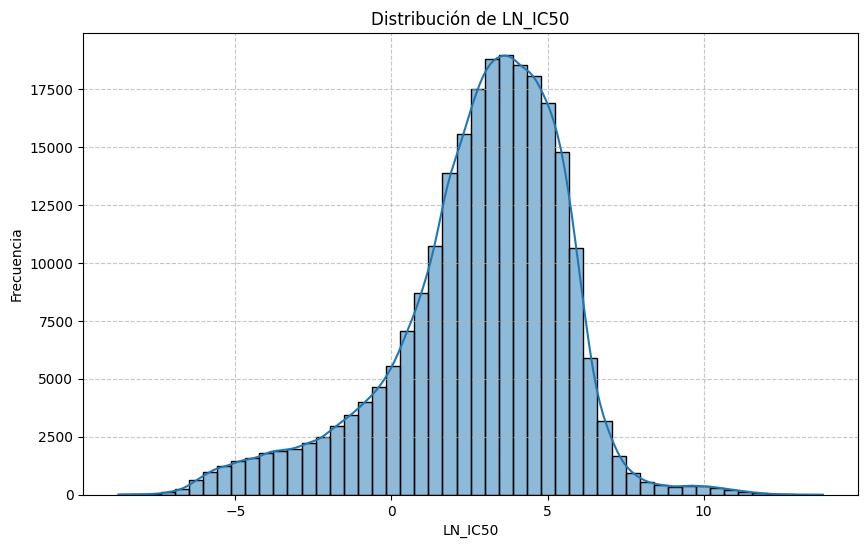

Media de LN_IC50: 2.8171
Mediana de LN_IC50: 3.2367
Desviación Estándar de LN_IC50: 2.7622
Valores Mínimos de LN_IC50: -8.7477
Valores Máximos de LN_IC50: 13.8202


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Usar la variable 'target' que contiene los valores de LN_IC50 del dataset original

plt.figure(figsize=(10, 6))
sns.histplot(target, kde=True, bins=50) # Usar 'target' directamente
plt.title('Distribución de LN_IC50')
plt.xlabel('LN_IC50')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Media de LN_IC50: {target.mean():.4f}")
print(f"Mediana de LN_IC50: {target.median():.4f}")
print(f"Desviación Estándar de LN_IC50: {target.std():.4f}")
print(f"Valores Mínimos de LN_IC50: {target.min():.4f}")
print(f"Valores Máximos de LN_IC50: {target.max():.4f}")

### Análisis Visual de los Datos

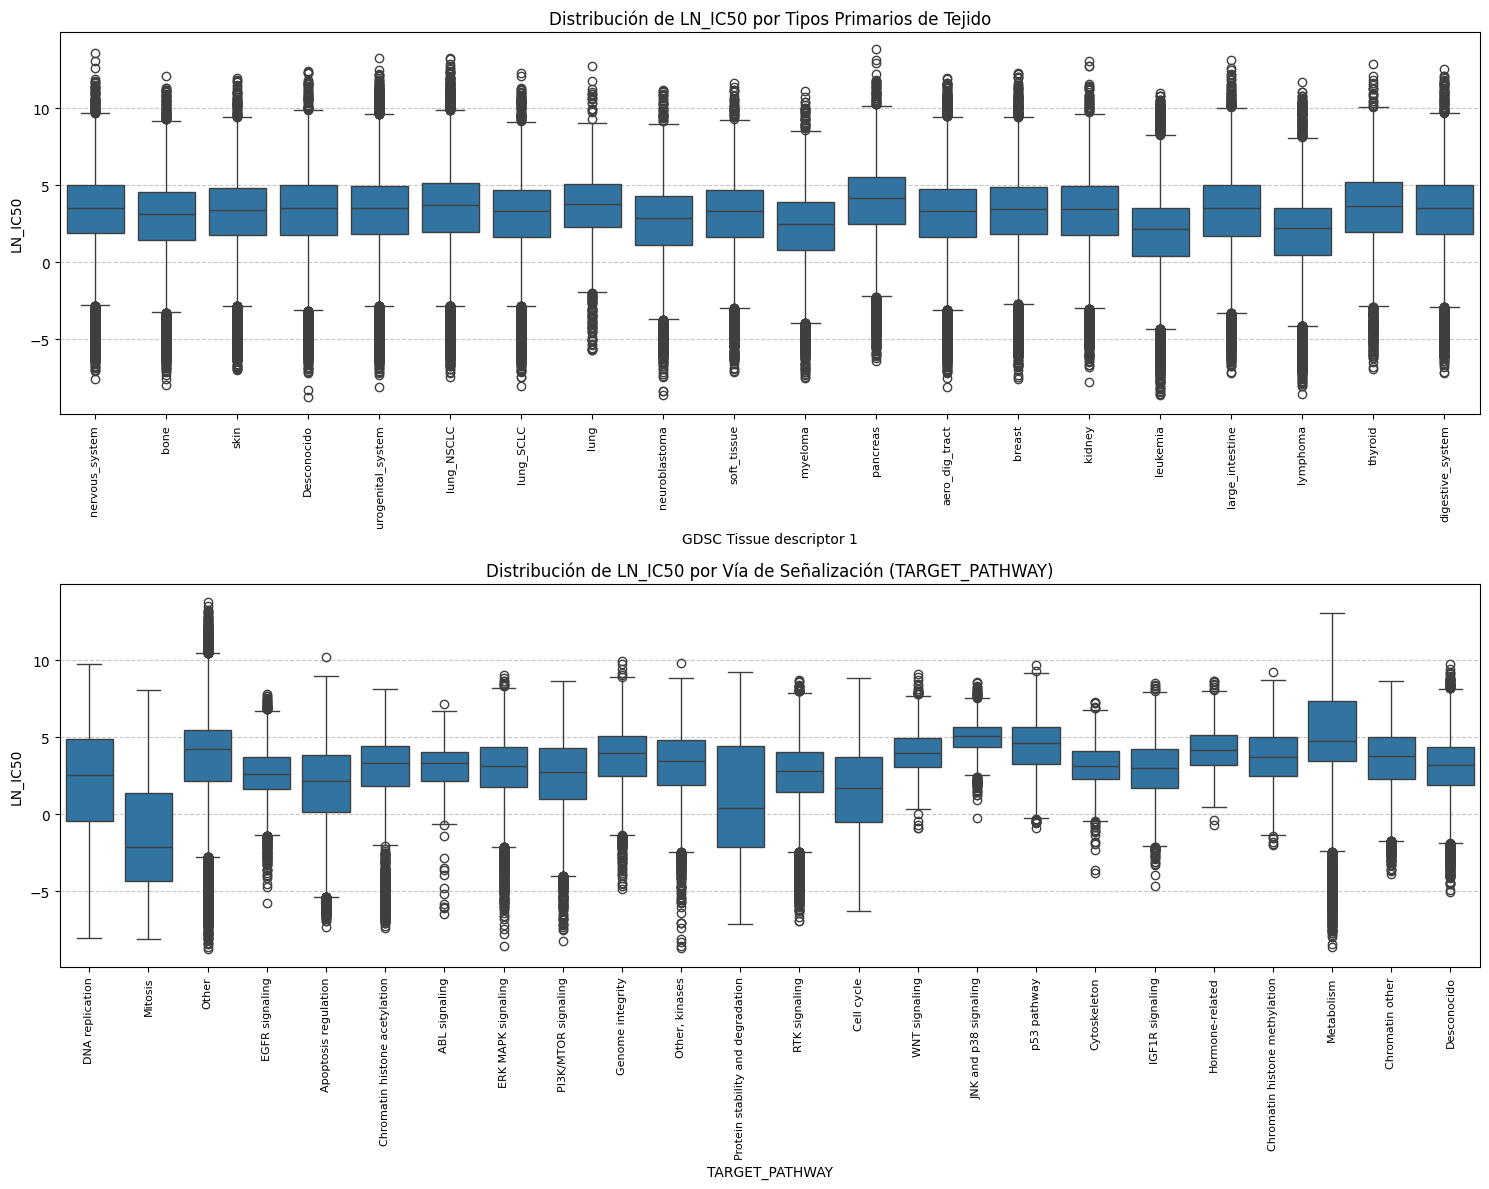

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame temporal para graficar, usando directamente 'target' y 'data'.
# 'target' contiene los valores de 'LN_IC50' y 'data' contiene los valores de 'GDSC Tissue descriptor 1'.
# Ambas variables están alineadas por índice antes de cualquier codificación o división de conjuntos.
plot_df_gdsc = pd.DataFrame({
    'LN_IC50': target,
    'GDSC Tissue descriptor 1': data['GDSC Tissue descriptor 1']
})

plot_df_target_pathway = pd.DataFrame({
    'LN_IC50': target,
    'TARGET_PATHWAY': data['TARGET_PATHWAY']
})

# Obtener el número de categorías únicas en 'GDSC Tissue descriptor 1' y 'TARGET_PATHWAY'
num_categories_gdsc = plot_df_gdsc['GDSC Tissue descriptor 1'].nunique()
num_categories_target_pathway = plot_df_target_pathway['TARGET_PATHWAY'].nunique()

# Ajustar el tamaño de la figura en función del número de categorías para una mejor legibilidad
# Se usará un tamaño fijo para los subplots en este caso para mantenerlos uniformes.
# Cambiamos a 2 filas, 1 columna para que se muestren uno encima del otro
fig, axes = plt.subplots(2, 1, figsize=(15, 12)) # 2 filas, 1 columna para dos boxplots, ajustamos el tamaño

# --- Primer Boxplot: GDSC Tissue descriptor 1 ---
sns.boxplot(x='GDSC Tissue descriptor 1', y='LN_IC50', data=plot_df_gdsc, showfliers=True, ax=axes[0])
axes[0].set_title('Distribución de LN_IC50 por Tipos Primarios de Tejido')
axes[0].set_xlabel('GDSC Tissue descriptor 1')
axes[0].set_ylabel('LN_IC50')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Rotar las etiquetas del eje x para una mejor legibilidad si hay muchas categorías
if num_categories_gdsc > 5:
    axes[0].tick_params(axis='x', rotation=90, labelsize=8)
else:
    axes[0].tick_params(axis='x', rotation=45, labelsize=10)

# --- Segundo Boxplot: TARGET_PATHWAY ---
sns.boxplot(x='TARGET_PATHWAY', y='LN_IC50', data=plot_df_target_pathway, showfliers=True, ax=axes[1])
axes[1].set_title('Distribución de LN_IC50 por Vía de Señalización (TARGET_PATHWAY)')
axes[1].set_xlabel('TARGET_PATHWAY')
axes[1].set_ylabel('LN_IC50')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Rotar las etiquetas del eje x para una mejor legibilidad si hay muchas categorías
if num_categories_target_pathway > 5:
    axes[1].tick_params(axis='x', rotation=90, labelsize=8)
else:
    axes[1].tick_params(axis='x', rotation=45, labelsize=10)

plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas o títulos se recorten
plt.show()

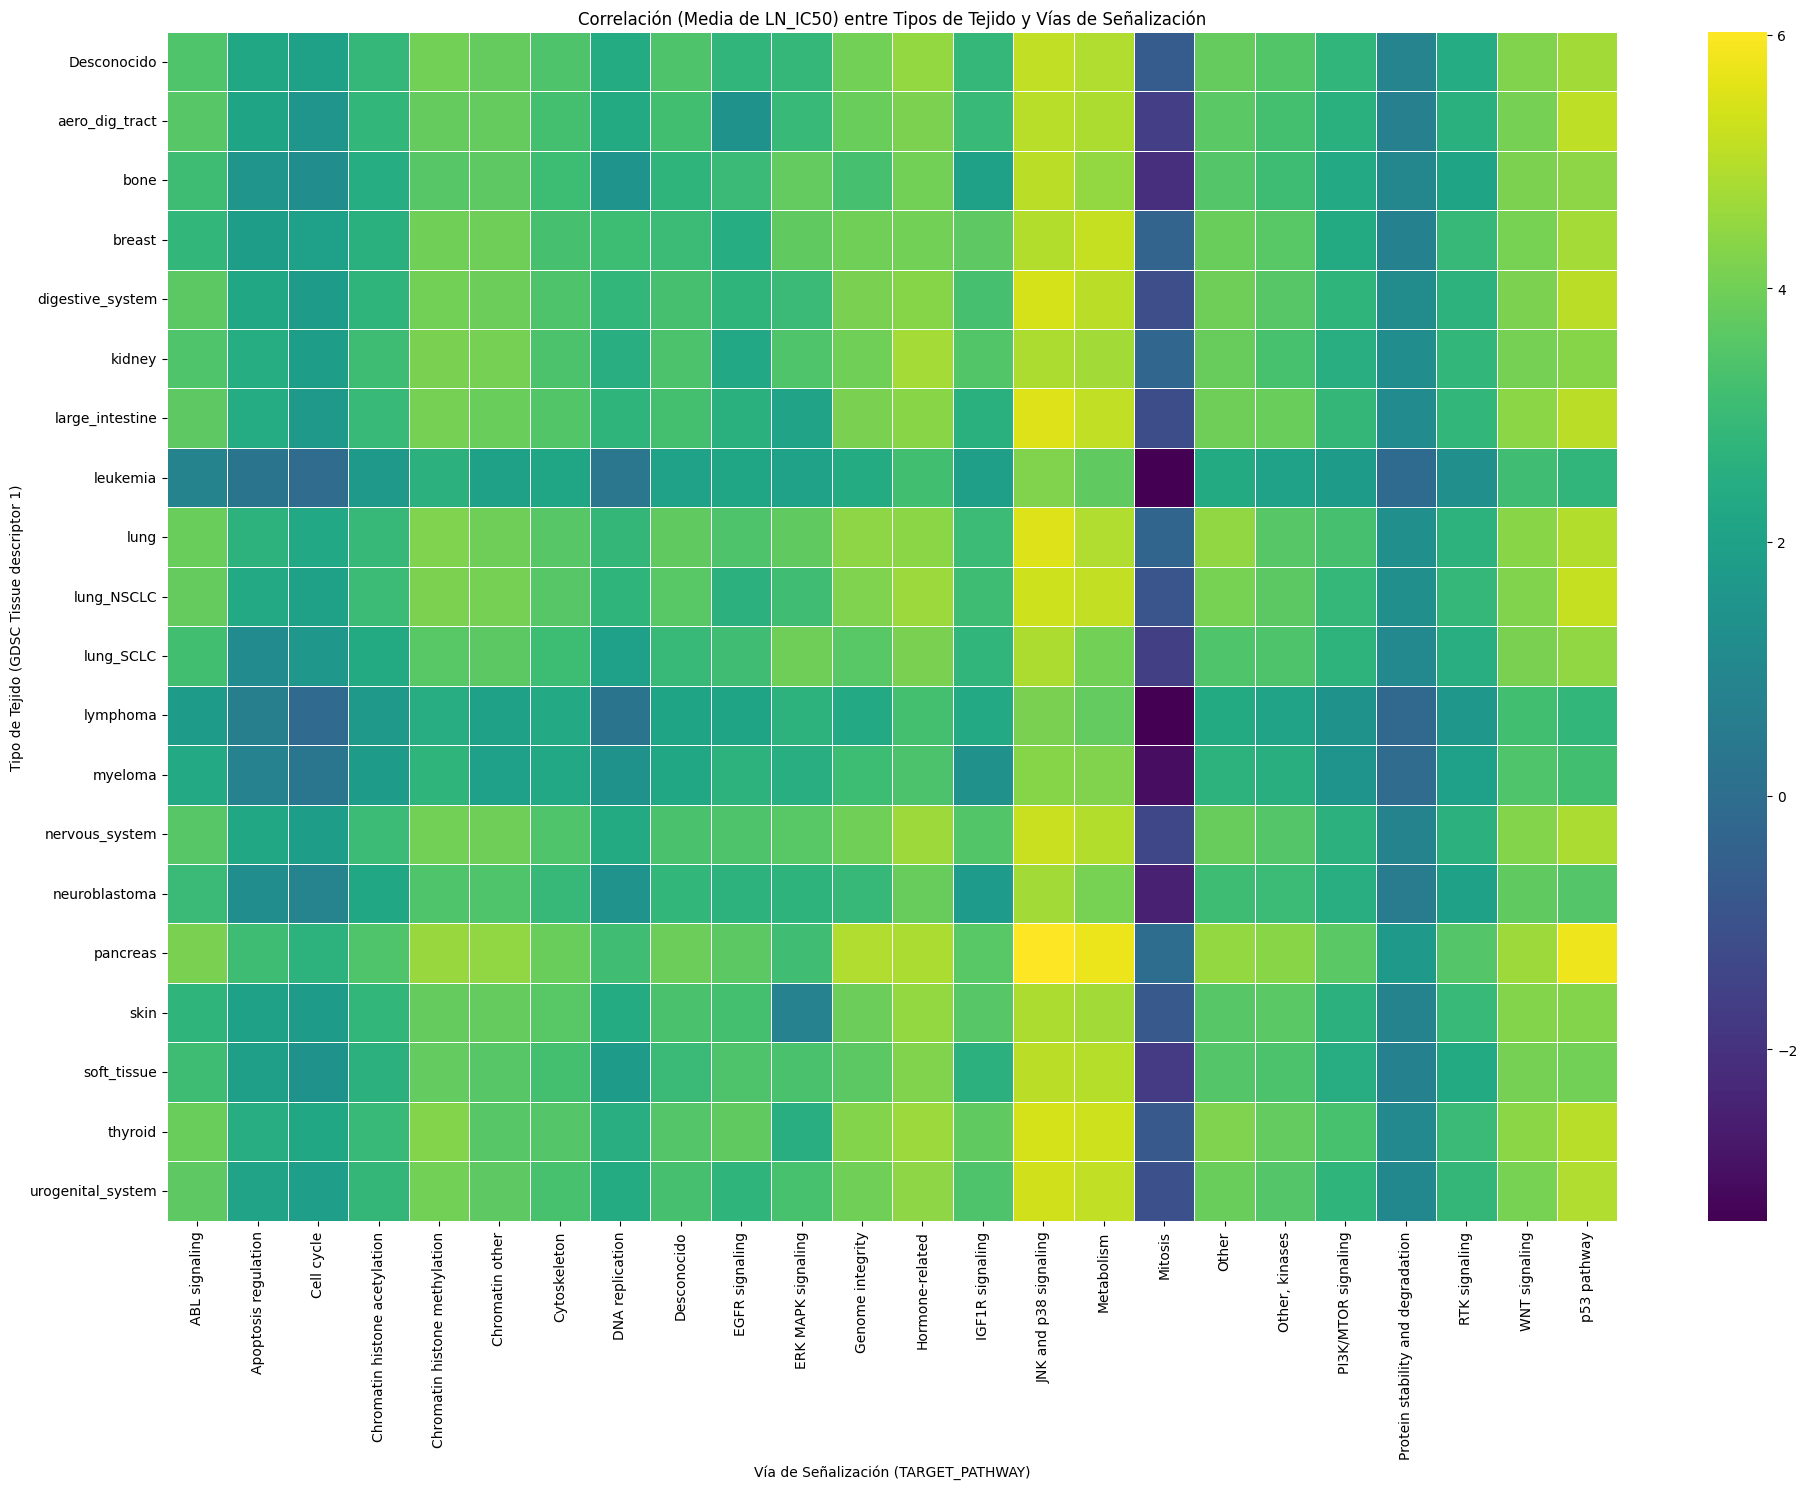

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame temporal con las variables relevantes
plot_df_correlation = pd.DataFrame({
    'LN_IC50': target,
    'GDSC Tissue descriptor 1': data['GDSC Tissue descriptor 1'],
    'TARGET_PATHWAY': data['TARGET_PATHWAY']
})

# Calcular el promedio de LN_IC50 para cada combinación de las variables categóricas
correlation_matrix = plot_df_correlation.groupby(['GDSC Tissue descriptor 1', 'TARGET_PATHWAY'])['LN_IC50'].mean().unstack()

# Ajustar el tamaño de la figura para acomodar el mapa de calor
plt.figure(figsize=(20, 15)) # Ajusta el tamaño según la cantidad de categorías

# Crear el mapa de calor
sns.heatmap(correlation_matrix, cmap='viridis', annot=False, fmt=".1f", linewidths=.5)
plt.title('Correlación (Media de LN_IC50) entre Tipos de Tejido y Vías de Señalización')
plt.xlabel('Vía de Señalización (TARGET_PATHWAY)')
plt.ylabel('Tipo de Tejido (GDSC Tissue descriptor 1)')
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas o títulos se recorten
plt.show()

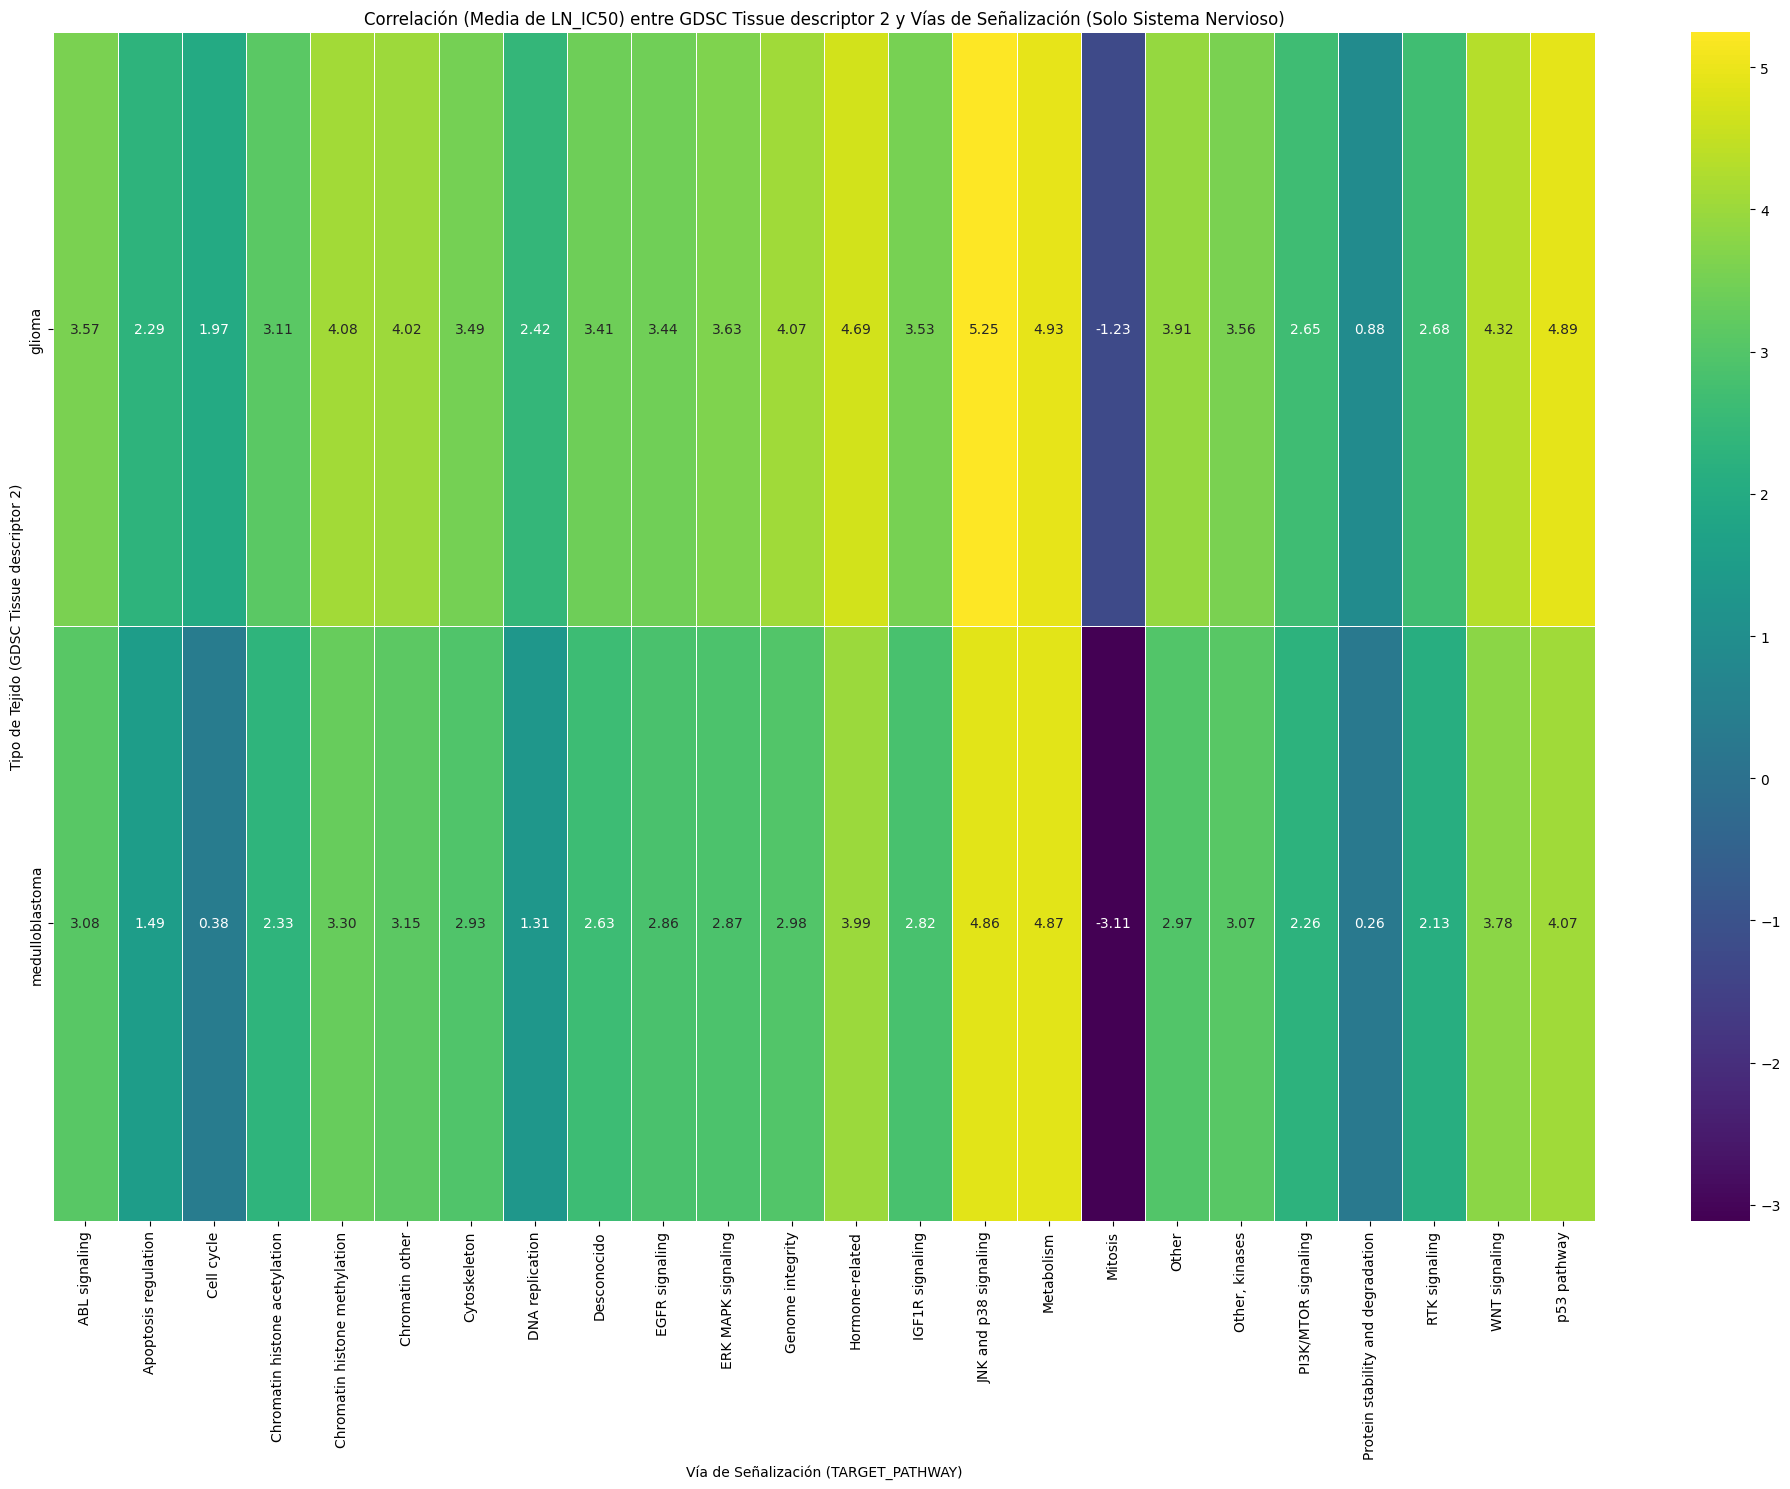

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear un DataFrame temporal con las variables relevantes, incluyendo GDSC Tissue descriptor 1 para filtrar
plot_df_correlation_filtered = pd.DataFrame({
    'LN_IC50': target,
    'GDSC Tissue descriptor 1': data['GDSC Tissue descriptor 1'],
    'GDSC Tissue descriptor 2': data['GDSC Tissue descriptor 2'],
    'TARGET_PATHWAY': data['TARGET_PATHWAY']
})

# Filtrar las filas donde 'GDSC Tissue descriptor 1' es 'nervous_system'
plot_df_correlation_filtered = plot_df_correlation_filtered[plot_df_correlation_filtered['GDSC Tissue descriptor 1'] == 'nervous_system']

# Calcular el promedio de LN_IC50 para cada combinación de las variables categóricas filtradas
correlation_matrix_filtered = plot_df_correlation_filtered.groupby(['GDSC Tissue descriptor 2', 'TARGET_PATHWAY'])['LN_IC50'].mean().unstack()

# Ajustar el tamaño de la figura para acomodar el mapa de calor
plt.figure(figsize=(20, 15)) # Ajusta el tamaño según la cantidad de categorías

# Crear el mapa de calor
sns.heatmap(correlation_matrix_filtered, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
# Update the title to reflect the actual filter used
plt.title('Correlación (Media de LN_IC50) entre GDSC Tissue descriptor 2 y Vías de Señalización (Solo Sistema Nervioso)')
plt.xlabel('Vía de Señalización (TARGET_PATHWAY)')
plt.ylabel('Tipo de Tejido (GDSC Tissue descriptor 2)')
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas o títulos se recorten
plt.show()

### Preprocesamiento de datos: One-Hot Encoding



In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import re # Importar la librería de expresiones regulares

# Identificar columnas categóricas
categorical_cols = X_train.select_dtypes(include='object').columns

# Crear un ColumnTransformer para aplicar OneHotEncoder solo a las columnas categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Mantener las columnas numéricas sin cambios
)

# Aplicar el preprocesamiento a los sets de entrenamiento y validación
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

# Obtener los nombres de las columnas para las características codificadas
cat_feature_names_only = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

feature_names = cat_feature_names_only.copy() # Empezar con los nombres de las características categóricas

# Si hay columnas numéricas, añadirlas a los nombres de las características
# Las columnas 'remainder' se añaden al final en el orden original
numeric_cols = X_train.select_dtypes(exclude='object').columns.tolist()
feature_names.extend(numeric_cols)

# Convertir los resultados a DataFrame para facilitar la visualización y manejo

X_train_encoded = pd.DataFrame(X_train_processed.toarray(), columns=feature_names, index=X_train.index)
X_valid_encoded = pd.DataFrame(X_valid_processed.toarray(), columns=feature_names, index=X_valid.index)

# Limpiar los nombres de las columnas para que sean compatibles con XGBoost y asegurar unicidad
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    seen_names = set()
    for col in cols:
        # Eliminar caracteres especiales que no le gustan a XGBoost y reemplazar espacios por guiones bajos
        new_col = re.sub(r'[\\\[\]<>]', '_', col) # Reemplazar [, ], <, >
        new_col = re.sub(r'[^a-zA-Z0-9_]', '', new_col) # Eliminar cualquier otro caracter no alfanumérico o guion bajo

        # Asegurar unicidad del nombre de columna
        original_new_col = new_col
        count = 1
        while new_col in seen_names:
            new_col = f"{original_new_col}_{count}"
            count += 1

        new_cols.append(new_col)
        seen_names.add(new_col)
    df.columns = new_cols
    return df

X_train_encoded = clean_col_names(X_train_encoded)
X_valid_encoded = clean_col_names(X_valid_encoded)

# Convertir las columnas de one-hot encoding a tipo booleano
# Asegurarse de que esta operación se haga después de la limpieza de nombres si se basa en nombres específicos
for col in X_train_encoded.columns:
    if X_train_encoded[col].dtype == 'float64' and X_train_encoded[col].isin([0.0, 1.0]).all():
        X_train_encoded[col] = X_train_encoded[col].astype(bool)
for col in X_valid_encoded.columns:
    if X_valid_encoded[col].dtype == 'float64' and X_valid_encoded[col].isin([0.0, 1.0]).all():
        X_valid_encoded[col] = X_valid_encoded[col].astype(bool)


print("Dimensiones de X_train_encoded:")
print(X_train_encoded.shape)
print("Primeras 5 filas de X_train_encoded:")
display(X_train_encoded.head())

print("\nDimensiones de X_valid_encoded:")
print(X_valid_encoded.shape)
print("Primeras 5 filas de X_valid_encoded:")
display(X_valid_encoded.head())

Dimensiones de X_train_encoded:
(193628, 1623)
Primeras 5 filas de X_train_encoded:


,CELL_LINE_NAME_22RV1,CELL_LINE_NAME_2313287,CELL_LINE_NAME_42MGBA,CELL_LINE_NAME_451Lu,CELL_LINE_NAME_5637,CELL_LINE_NAME_639V,CELL_LINE_NAME_647V,CELL_LINE_NAME_697,CELL_LINE_NAME_769P,CELL_LINE_NAME_7860,...,TARGET_PATHWAY_JNKandp38signaling,TARGET_PATHWAY_Metabolism,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,TARGET_PATHWAY_Otherkinases,TARGET_PATHWAY_PI3KMTORsignaling,TARGET_PATHWAY_Proteinstabilityanddegradation,TARGET_PATHWAY_RTKsignaling,TARGET_PATHWAY_WNTsignaling,TARGET_PATHWAY_p53pathway
226764,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
169505,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
28185,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
150708,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
57432,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Dimensiones de X_valid_encoded:
(48407, 1623)
Primeras 5 filas de X_valid_encoded:


,CELL_LINE_NAME_22RV1,CELL_LINE_NAME_2313287,CELL_LINE_NAME_42MGBA,CELL_LINE_NAME_451Lu,CELL_LINE_NAME_5637,CELL_LINE_NAME_639V,CELL_LINE_NAME_647V,CELL_LINE_NAME_697,CELL_LINE_NAME_769P,CELL_LINE_NAME_7860,...,TARGET_PATHWAY_JNKandp38signaling,TARGET_PATHWAY_Metabolism,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,TARGET_PATHWAY_Otherkinases,TARGET_PATHWAY_PI3KMTORsignaling,TARGET_PATHWAY_Proteinstabilityanddegradation,TARGET_PATHWAY_RTKsignaling,TARGET_PATHWAY_WNTsignaling,TARGET_PATHWAY_p53pathway
155982,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
214308,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
125942,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
216387,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
68191,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Distribución de la variable objetivo en los sets de Entrenamiento y Validación

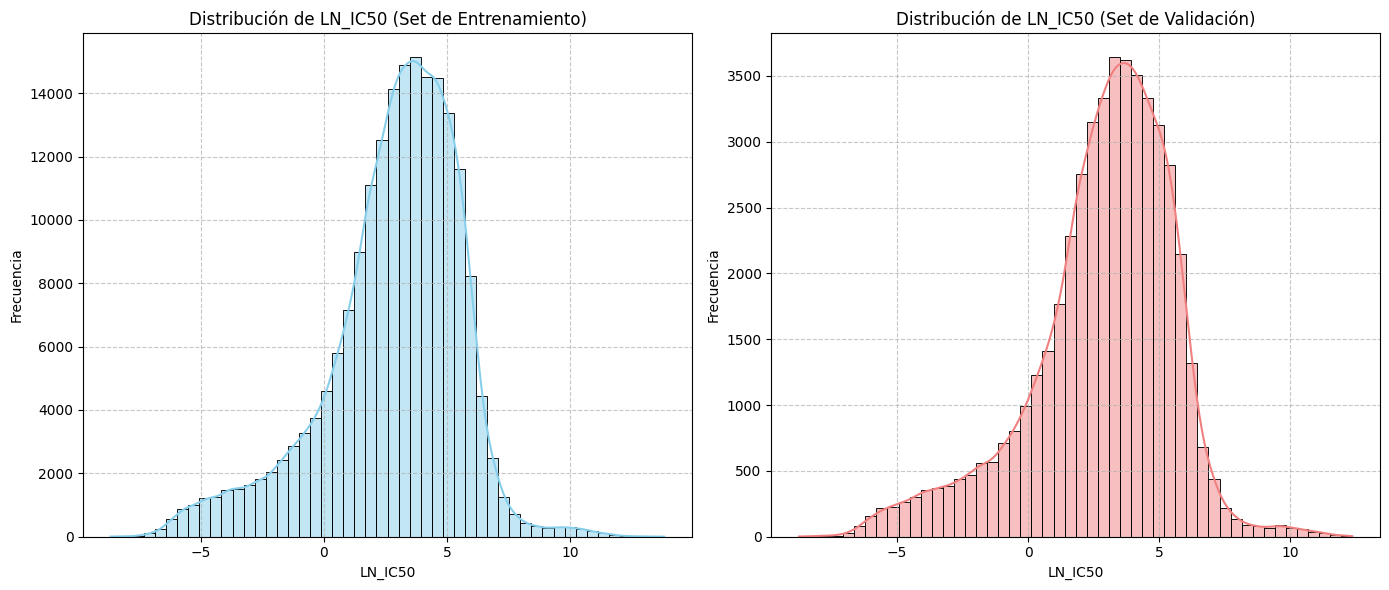

Estadísticas para y_train:
  Media: 2.8156
  Mediana: 3.2367
  Desviación Estándar: 2.7655

Estadísticas para y_valid:
  Media: 2.8231
  Mediana: 3.2369
  Desviación Estándar: 2.7488


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(y_train, kde=True, bins=50, color='skyblue')
plt.title('Distribución de LN_IC50 (Set de Entrenamiento)')
plt.xlabel('LN_IC50')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.histplot(y_valid, kde=True, bins=50, color='lightcoral')
plt.title('Distribución de LN_IC50 (Set de Validación)')
plt.xlabel('LN_IC50')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Estadísticas para y_train:")
print(f"  Media: {y_train.mean():.4f}")
print(f"  Mediana: {y_train.median():.4f}")
print(f"  Desviación Estándar: {y_train.std():.4f}")

print("\nEstadísticas para y_valid:")
print(f"  Media: {y_valid.mean():.4f}")
print(f"  Mediana: {y_valid.median():.4f}")
print(f"  Desviación Estándar: {y_valid.std():.4f}")

### Modelo de XGBoost Regressor



Entrenando XGBoost Regressor...
Entrenamiento completado.

Error Absoluto Medio (MAE) del XGBoost: 0.9807
Root Mean Squared Error (RMSE) para modelo_1 con nuevo filtro: 1.2759
R-squared (R2 Score) para modelo_1 con nuevo filtro: 0.7845


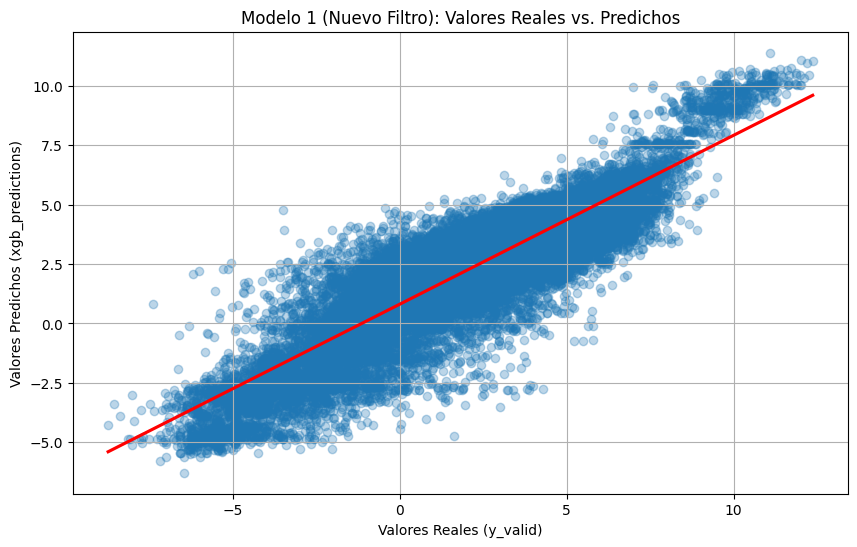

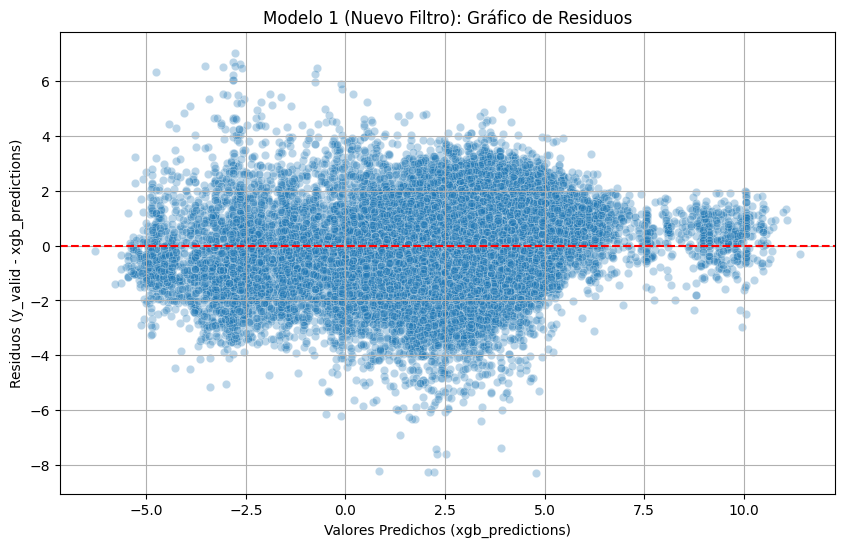

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=-1, random_state=0) # n_jobs=-1 para usar todos los núcleos disponibles

# Entrenar el modelo
print("Entrenando XGBoost Regressor...")
xgb_model.fit(X_train_encoded, y_train,
              eval_set=[(X_valid_encoded, y_valid)], verbose=False) # Evaluar en el set de validación
print("Entrenamiento completado.")

# Realizar predicciones en el set de validación
xgb_predictions = xgb_model.predict(X_valid_encoded)

# Evaluar el rendimiento del modelo
xgb_mae = mean_absolute_error(y_valid, xgb_predictions)
print(f"\nError Absoluto Medio (MAE) del XGBoost: {xgb_mae:.4f}")

# Calcular RMSE
rmse_1_new = np.sqrt(mean_squared_error(y_valid, xgb_predictions))
print(f"Root Mean Squared Error (RMSE) para modelo_1 con nuevo filtro: {rmse_1_new:.4f}")

# Calcular R-squared
r2_1_new = r2_score(y_valid, xgb_predictions)
print(f"R-squared (R2 Score) para modelo_1 con nuevo filtro: {r2_1_new:.4f}")

# 1. Gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.regplot(x=y_valid, y=xgb_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valores Reales (y_valid)')
plt.ylabel('Valores Predichos (xgb_predictions)')
plt.title('Modelo 1 (Nuevo Filtro): Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
residuals_1_new = y_valid - xgb_predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=xgb_predictions, y=residuals_1_new, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos (xgb_predictions)')
plt.ylabel('Residuos (y_valid - xgb_predictions)')
plt.title('Modelo 1 (Nuevo Filtro): Gráfico de Residuos')
plt.grid(True)
plt.show()

### Modelo de  CatBoost Regressor



In [ ]:
import sys
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.9 MB/s eta 0:00:00


Entrenando CatBoost Regressor...
Entrenamiento completado.

Error Absoluto Medio (MAE) del CatBoost: 0.9430
Root Mean Squared Error (RMSE) del CatBoost: 1.2330
R-squared (R2 Score) del CatBoost: 0.7988


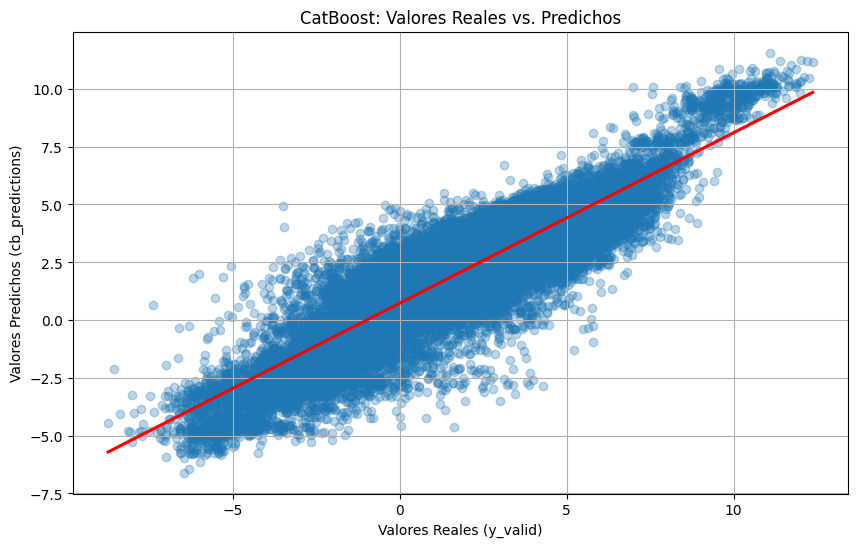

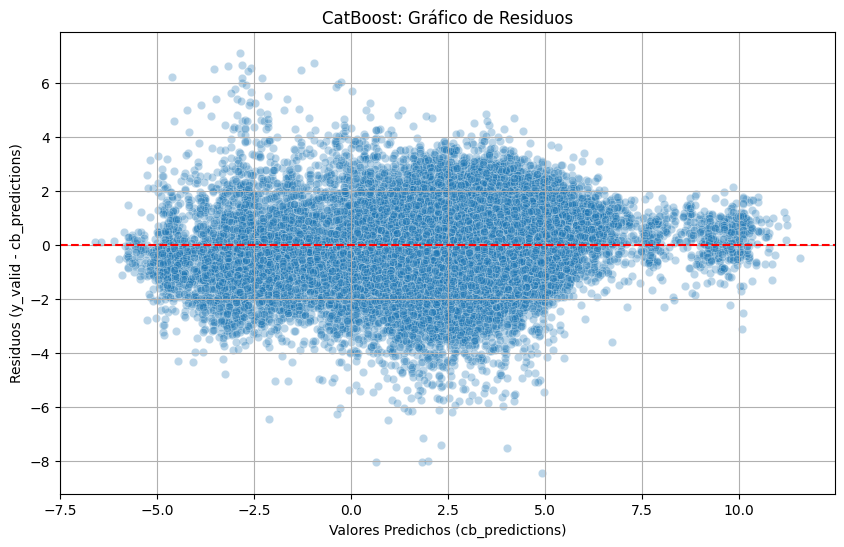

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo CatBoost Regressor
# Para CatBoost, dado que las características ya están one-hot encoded, no necesitamos pasar cat_features.
cb_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=10,
                             random_seed=0, verbose=False, # verbose=False para no imprimir el progreso
                             allow_writing_files=False) # Para evitar errores en algunos entornos

# Entrenar el modelo
print("Entrenando CatBoost Regressor...")
cb_model.fit(X_train_encoded, y_train,
              eval_set=(X_valid_encoded, y_valid),
              early_stopping_rounds=50, # Early stopping para evitar sobreajuste
              verbose=False)
print("Entrenamiento completado.")

# Realizar predicciones en el set de validación
cb_predictions = cb_model.predict(X_valid_encoded)

# Evaluar el rendimiento del modelo
cb_mae = mean_absolute_error(y_valid, cb_predictions)
print(f"\nError Absoluto Medio (MAE) del CatBoost: {cb_mae:.4f}")

# Calcular RMSE
cb_rmse = np.sqrt(mean_squared_error(y_valid, cb_predictions))
print(f"Root Mean Squared Error (RMSE) del CatBoost: {cb_rmse:.4f}")

# Calcular R-squared
cb_r2 = r2_score(y_valid, cb_predictions)
print(f"R-squared (R2 Score) del CatBoost: {cb_r2:.4f}")

# 1. Gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.regplot(x=y_valid, y=cb_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valores Reales (y_valid)')
plt.ylabel('Valores Predichos (cb_predictions)')
plt.title('CatBoost: Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
cb_residuals = y_valid - cb_predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cb_predictions, y=cb_residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos (cb_predictions)')
plt.ylabel('Residuos (y_valid - cb_predictions)')
plt.title('CatBoost: Gráfico de Residuos')
plt.grid(True)
plt.show()

### Análisis de Importancia de Características




--- Importancia de Características para XGBoost ---
Top 15 características para XGBoost:


,Feature,Importance
1615,TARGET_PATHWAY_Mitosis,1.022997e+06
1082,DRUG_NAME_Dactinomycin,6.472576e+05
1062,DRUG_NAME_Bortezomib,4.951858e+05
1595,TARGET_antioxidantproteins,4.881083e+05
1579,TARGET_TOP1,4.825302e+05
1219,DRUG_NAME_Romidepsin,4.012409e+05
1403,GrowthProperties_Suspension,3.845864e+05
1235,DRUG_NAME_Sepantroniumbromide,3.824579e+05
1526,TARGET_Metabolism,3.268929e+05
1493,TARGET_HSP90,2.701259e+05


/tmp/ipykernel_6640/2791993601.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_importance_df.head(15), palette='viridis')


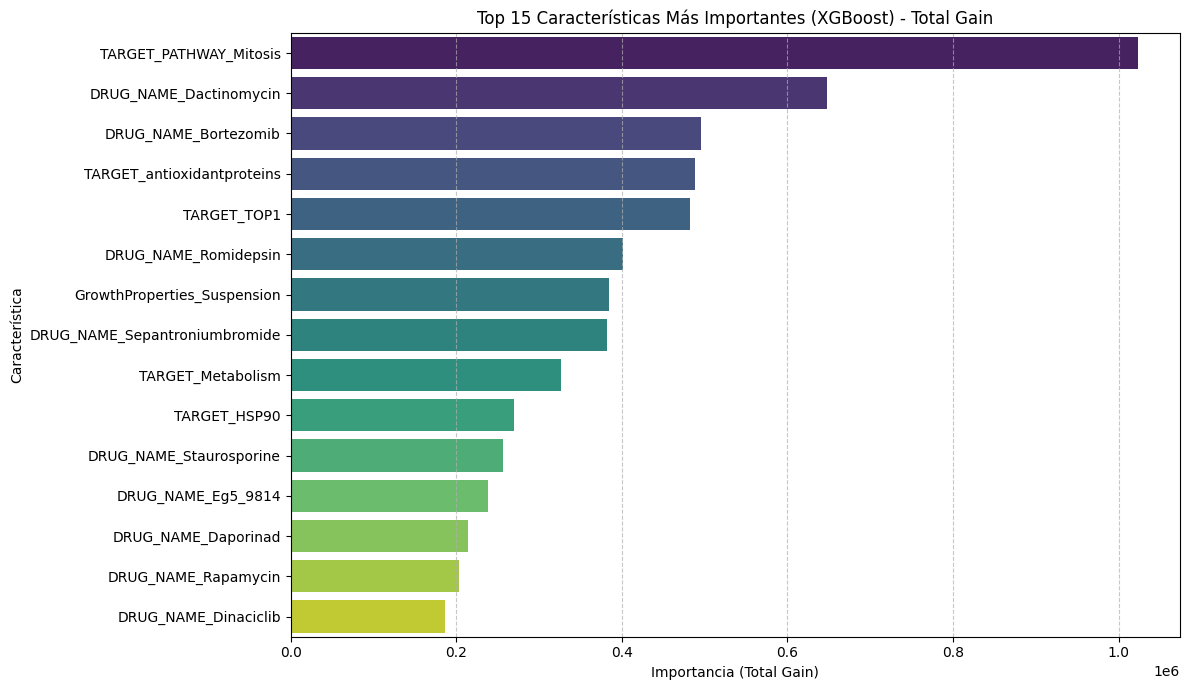

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- XGBoost Feature Importance ---
print("\n--- Importancia de Características para XGBoost ---")

# Obtener las importancias de las características del modelo entrenado
# Usamos get_booster().get_score() con importance_type='total_gain' para obtener valores no normalizados y de mayor magnitud
xgb_feature_scores = xgb_model.get_booster().get_score(importance_type='total_gain')

# Obtener los nombres de las características
feature_names = X_train_encoded.columns

# Asegurarnos de que todas las características tengan un score, si alguna no aparece, su score es 0
xgb_feature_importances = pd.Series(xgb_feature_scores).reindex(feature_names, fill_value=0)

# Crear un DataFrame para mejor visualización
xgb_importance_df = pd.DataFrame({
    'Feature': xgb_feature_importances.index,
    'Importance': xgb_feature_importances.values
})

# Ordenar por importancia y seleccionar las top N
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)

# Mostrar las top 15 características
print("Top 15 características para XGBoost:")
display(xgb_importance_df.head(15))

# Visualizar las top 15 características
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df.head(15), palette='viridis')
plt.title('Top 15 Características Más Importantes (XGBoost) - Total Gain')
plt.xlabel('Importancia (Total Gain)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Importancia de Características para CatBoost ---
Top 15 características para CatBoost:


,Feature,Importance
1615,TARGET_PATHWAY_Mitosis,5.244881
1579,TARGET_TOP1,3.567472
1528,TARGET_Microtubulestabiliser,3.490158
1595,TARGET_antioxidantproteins,3.475779
1403,GrowthProperties_Suspension,3.370483
1562,TARGET_RNApolymerase,2.813431
1082,DRUG_NAME_Dactinomycin,2.627666
1526,TARGET_Metabolism,2.404305
1062,DRUG_NAME_Bortezomib,2.231258
1527,TARGET_Microtubuledestabiliser,2.196634


/tmp/ipykernel_6640/2138753972.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=cb_importance_df.head(15), palette='magma')


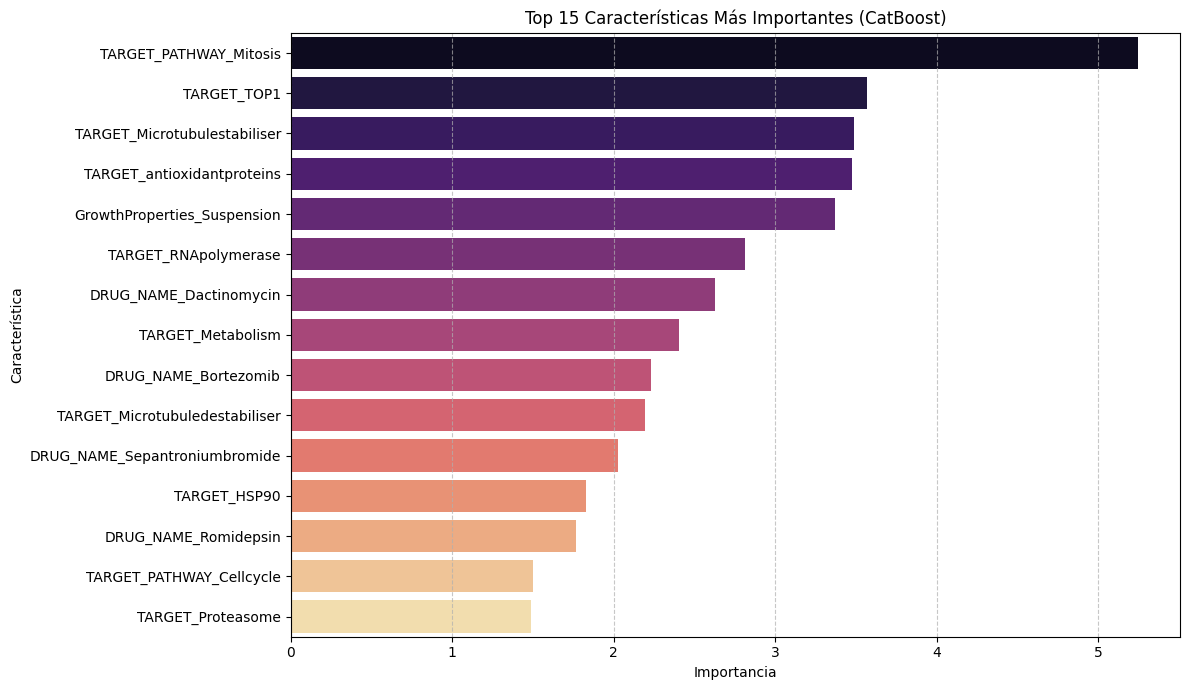

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- CatBoost Feature Importance ---
print("\n--- Importancia de Características para CatBoost ---")

# Obtener las importancias de las características del modelo entrenado
cb_feature_importances = cb_model.get_feature_importance()

# Obtener los nombres de las características
feature_names = X_train_encoded.columns

# Crear un DataFrame para mejor visualización
cb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': cb_feature_importances
})

# Ordenar por importancia y seleccionar las top N
cb_importance_df = cb_importance_df.sort_values(by='Importance', ascending=False)

# Mostrar las top 15 características
print("Top 15 características para CatBoost:")
display(cb_importance_df.head(15))

# Visualizar las top 15 características
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=cb_importance_df.head(15), palette='magma')
plt.title('Top 15 Características Más Importantes (CatBoost)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Preparar Datos para Validación Cruzada



In [ ]:
import pandas as pd

# 1. Concatenar X_train_encoded y X_valid_encoded
X_combined = pd.concat([X_train_encoded, X_valid_encoded], axis=0)

# 2. Concatenar y_train e y_valid
y_combined = pd.concat([y_train, y_valid], axis=0)

print("Dimensiones de X_combined:")
print(X_combined.shape)
print("Primeras 5 filas de X_combined:")
display(X_combined.head())

print("\nDimensiones de y_combined:")
print(y_combined.shape)
print("Primeras 5 filas de y_combined:")
display(y_combined.head())

Dimensiones de X_combined:
(242035, 1623)
Primeras 5 filas de X_combined:


,CELL_LINE_NAME_22RV1,CELL_LINE_NAME_2313287,CELL_LINE_NAME_42MGBA,CELL_LINE_NAME_451Lu,CELL_LINE_NAME_5637,CELL_LINE_NAME_639V,CELL_LINE_NAME_647V,CELL_LINE_NAME_697,CELL_LINE_NAME_769P,CELL_LINE_NAME_7860,...,TARGET_PATHWAY_JNKandp38signaling,TARGET_PATHWAY_Metabolism,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,TARGET_PATHWAY_Otherkinases,TARGET_PATHWAY_PI3KMTORsignaling,TARGET_PATHWAY_Proteinstabilityanddegradation,TARGET_PATHWAY_RTKsignaling,TARGET_PATHWAY_WNTsignaling,TARGET_PATHWAY_p53pathway
226764,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
169505,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
28185,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
150708,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
57432,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Dimensiones de y_combined:
(242035,)
Primeras 5 filas de y_combined:


,LN_IC50
226764,1.270521
169505,8.767445
28185,5.028930
150708,6.488667
57432,3.705918


In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
import numpy as np

print("Necessary libraries and models for K-Fold Cross-Validation imported successfully.")

Necessary libraries and models for K-Fold Cross-Validation imported successfully.


In [ ]:
models = {
    'XGBoostRegressor': xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=-1, random_state=0, verbosity=0), # verbosity=0 to suppress output
    'CatBoostRegressor': CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=10, random_seed=0, verbose=0, allow_writing_files=False) # verbose=0 to suppress output
}

print("Models initialized successfully.")

Models initialized successfully.


In [ ]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

# Diccionarios para almacenar los resultados
results = {
    'XGBoostRegressor': {'MAE': [], 'RMSE': [], 'R2': []},
    'CatBoostRegressor': {'MAE': [], 'RMSE': [], 'R2': []}
}

print(f"K-Fold splitter initialized with {n_splits} splits.")
print("Results dictionaries initialized.")

K-Fold splitter initialized with 5 splits.
Results dictionaries initialized.


In [ ]:
for model_name, model in models.items():
    print(f"\nRealizando validación cruzada para: {model_name}")
    fold_count = 1
    for train_index, test_index in kf.split(X_combined, y_combined):
        X_train_fold, X_test_fold = X_combined.iloc[train_index], X_combined.iloc[test_index]
        y_train_fold, y_test_fold = y_combined.iloc[train_index], y_combined.iloc[test_index]

        # Entrenar el modelo
        print(f"  Fold {fold_count}/{n_splits} - Entrenando {model_name}...")
        if model_name == 'XGBoostRegressor':
            model.fit(X_train_fold, y_train_fold, eval_set=[(X_test_fold, y_test_fold)], verbose=False)
        elif model_name == 'CatBoostRegressor':
            model.fit(X_train_fold, y_train_fold, eval_set=(X_test_fold, y_test_fold), early_stopping_rounds=50, verbose=False)
        else:
            model.fit(X_train_fold, y_train_fold)
        print(f"  Fold {fold_count}/{n_splits} - Entrenamiento completado.")

        # Realizar predicciones
        predictions = model.predict(X_test_fold)

        # Calcular métricas
        mae = mean_absolute_error(y_test_fold, predictions)
        rmse = np.sqrt(mean_squared_error(y_test_fold, predictions))
        r2 = r2_score(y_test_fold, predictions)

        # Almacenar resultados
        results[model_name]['MAE'].append(mae)
        results[model_name]['RMSE'].append(rmse)
        results[model_name]['R2'].append(r2)

        print(f"  Fold {fold_count}/{n_splits} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
        fold_count += 1

print("\nK-Fold Cross-Validation completada para todos los modelos.")


Realizando validación cruzada para: XGBoostRegressor
  Fold 1/5 - Entrenando XGBoostRegressor...
  Fold 1/5 - Entrenamiento completado.
  Fold 1/5 - MAE: 0.9874, RMSE: 1.2854, R2: 0.7840
  Fold 2/5 - Entrenando XGBoostRegressor...
  Fold 2/5 - Entrenamiento completado.
  Fold 2/5 - MAE: 0.9847, RMSE: 1.2807, R2: 0.7859
  Fold 3/5 - Entrenando XGBoostRegressor...
  Fold 3/5 - Entrenamiento completado.
  Fold 3/5 - MAE: 0.9893, RMSE: 1.2878, R2: 0.7842
  Fold 4/5 - Entrenando XGBoostRegressor...
  Fold 4/5 - Entrenamiento completado.
  Fold 4/5 - MAE: 0.9799, RMSE: 1.2751, R2: 0.7854
  Fold 5/5 - Entrenando XGBoostRegressor...
  Fold 5/5 - Entrenamiento completado.
  Fold 5/5 - MAE: 0.9894, RMSE: 1.2855, R2: 0.7819

Realizando validación cruzada para: CatBoostRegressor
  Fold 1/5 - Entrenando CatBoostRegressor...
  Fold 1/5 - Entrenamiento completado.
  Fold 1/5 - MAE: 0.9493, RMSE: 1.2421, R2: 0.7983
  Fold 2/5 - Entrenando CatBoostRegressor...
  Fold 2/5 - Entrenamiento completado.
  

In [ ]:
print("\n--- Resumen de la Validación Cruzada (Métricas Promedio) ---")
print("\nModelo                      | MAE Promedio | RMSE Promedio | R2 Promedio")
print("----------------------------|--------------|---------------|-------------")

for model_name, metrics in results.items():
    avg_mae = np.mean(metrics['MAE'])
    avg_rmse = np.mean(metrics['RMSE'])
    avg_r2 = np.mean(metrics['R2'])
    print(f"{model_name:<27} | {avg_mae:<12.4f} | {avg_rmse:<13.4f} | {avg_r2:<11.4f}")

print("----------------------------|--------------|---------------|-------------")


--- Resumen de la Validación Cruzada (Métricas Promedio) ---

Modelo                      | MAE Promedio | RMSE Promedio | R2 Promedio
----------------------------|--------------|---------------|-------------
XGBoostRegressor            | 0.9865       | 1.2835        | 0.7844     
CatBoostRegressor           | 0.9475       | 1.2398        | 0.7985     
----------------------------|--------------|---------------|-------------


### Análisis de Importancia de Características (Post-Validación Cruzada)



--- Importancia de Características para XGBoost (Post-CV) ---
Top 15 características para XGBoost (Post-CV):


,Feature,Importance
1615,TARGET_PATHWAY_Mitosis,1.015075e+06
1082,DRUG_NAME_Dactinomycin,6.588401e+05
1595,TARGET_antioxidantproteins,5.075067e+05
1579,TARGET_TOP1,5.064369e+05
1062,DRUG_NAME_Bortezomib,4.820735e+05
1219,DRUG_NAME_Romidepsin,4.068645e+05
1403,GrowthProperties_Suspension,3.892067e+05
1235,DRUG_NAME_Sepantroniumbromide,3.673396e+05
1526,TARGET_Metabolism,3.290896e+05
1493,TARGET_HSP90,2.771657e+05


/tmp/ipykernel_6640/3189351160.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_cv_importance_df.head(15), palette='viridis')


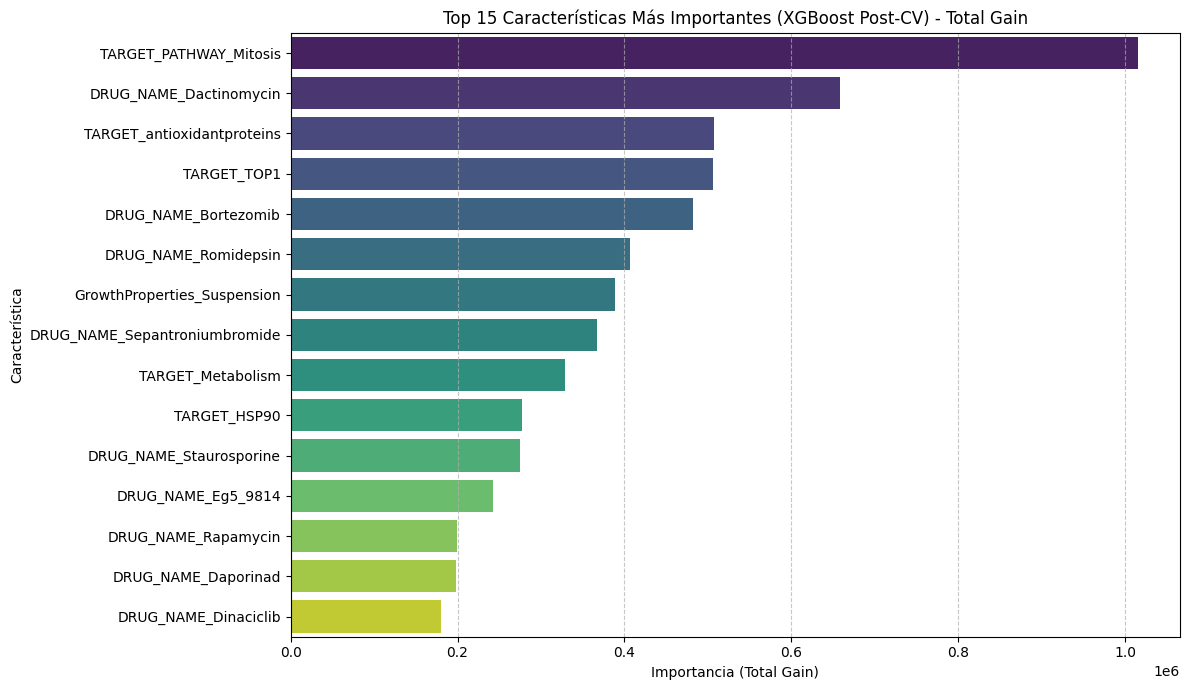

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- XGBoost Feature Importance (Post-CV) ---
print("\n--- Importancia de Características para XGBoost (Post-CV) ---")

# Obtener las importancias de las características del modelo entrenado (último fold de CV)
xgb_cv_model = models['XGBoostRegressor']
xgb_cv_feature_scores = xgb_cv_model.get_booster().get_score(importance_type='total_gain')

# Obtener los nombres de las características del conjunto combinado
feature_names_combined = X_combined.columns

# Asegurarnos de que todas las características tengan un score, si alguna no aparece, su score es 0
xgb_cv_feature_importances = pd.Series(xgb_cv_feature_scores).reindex(feature_names_combined, fill_value=0)

# Crear un DataFrame para mejor visualización
xgb_cv_importance_df = pd.DataFrame({
    'Feature': xgb_cv_feature_importances.index,
    'Importance': xgb_cv_feature_importances.values
})

# Ordenar por importancia y seleccionar las top N
xgb_cv_importance_df = xgb_cv_importance_df.sort_values(by='Importance', ascending=False)

# Mostrar las top 15 características
print("Top 15 características para XGBoost (Post-CV):")
display(xgb_cv_importance_df.head(15))

# Visualizar las top 15 características
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_cv_importance_df.head(15), palette='viridis')
plt.title('Top 15 Características Más Importantes (XGBoost Post-CV) - Total Gain')
plt.xlabel('Importancia (Total Gain)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Importancia de Características para CatBoost (Post-CV) ---
Top 15 características para CatBoost (Post-CV):


,Feature,Importance
1615,TARGET_PATHWAY_Mitosis,5.153682
1579,TARGET_TOP1,3.631947
1595,TARGET_antioxidantproteins,3.589714
1528,TARGET_Microtubulestabiliser,3.513855
1403,GrowthProperties_Suspension,3.443440
1082,DRUG_NAME_Dactinomycin,3.200314
1062,DRUG_NAME_Bortezomib,2.391439
1526,TARGET_Metabolism,2.367853
1562,TARGET_RNApolymerase,2.336766
1527,TARGET_Microtubuledestabiliser,2.301534


/tmp/ipykernel_6640/1724003461.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=cb_cv_importance_df.head(15), palette='magma')


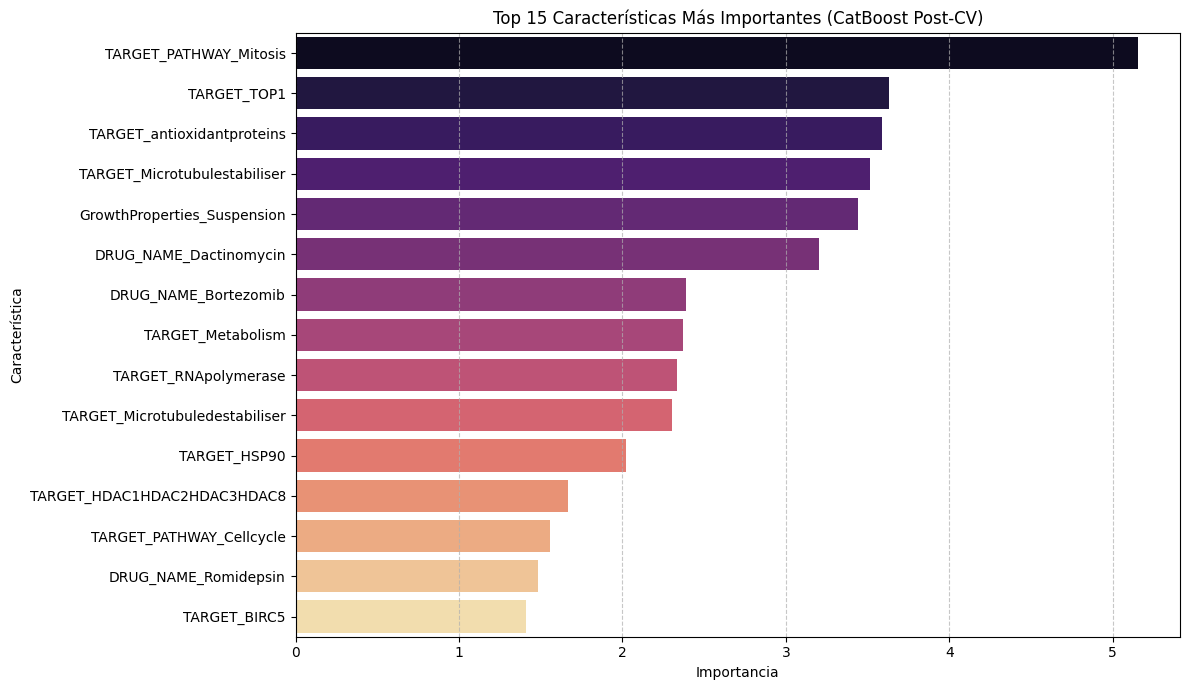

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- CatBoost Feature Importance (Post-CV) ---
print("\n--- Importancia de Características para CatBoost (Post-CV) ---")

# Obtener las importancias de las características del modelo entrenado (último fold de CV)
cb_cv_model = models['CatBoostRegressor']
cb_cv_feature_importances = cb_cv_model.get_feature_importance()

# Obtener los nombres de las características del conjunto combinado
feature_names_combined = X_combined.columns

# Crear un DataFrame para mejor visualización
cb_cv_importance_df = pd.DataFrame({
    'Feature': feature_names_combined,
    'Importance': cb_cv_feature_importances
})

# Ordenar por importancia y seleccionar las top N
cb_cv_importance_df = cb_cv_importance_df.sort_values(by='Importance', ascending=False)

# Mostrar las top 15 características
print("Top 15 características para CatBoost (Post-CV):")
display(cb_cv_importance_df.head(15))

# Visualizar las top 15 características
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=cb_cv_importance_df.head(15), palette='magma')
plt.title('Top 15 Características Más Importantes (CatBoost Post-CV)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()